In [46]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings
warnings.filterwarnings("ignore")

In [47]:
df = pd.read_csv(r"D:\Projects\StudentMarksPredict\data\marksheet.csv")
df.head()

,id,Name,Gender,Age,Section,Science,English,History,Maths
0,1,Bronnie,Female,13,C,21,81,62,49
1,2,Lemmie,Male,15,B,29,41,17,40
2,3,Danya,Female,14,C,12,87,16,96
3,4,Denna,Female,14,B,15,53,82,33
4,5,Jocelin,Male,14,A,43,6,3,21


In [48]:
df.shape

(250, 9)

In [49]:
df.columns

Index(['id', 'Name', 'Gender', 'Age', 'Section', 'Science', 'English',
       'History', 'Maths'],
      dtype='object')

In [50]:
df.dtypes

id          int64
Name       object
Gender     object
Age         int64
Section    object
Science     int64
English     int64
History     int64
Maths       int64
dtype: object

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       250 non-null    int64 
 1   Name     250 non-null    object
 2   Gender   250 non-null    object
 3   Age      250 non-null    int64 
 4   Section  250 non-null    object
 5   Science  250 non-null    int64 
 6   English  250 non-null    int64 
 7   History  250 non-null    int64 
 8   Maths    250 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 17.7+ KB


In [52]:
df.isnull().sum()

id         0
Name       0
Gender     0
Age        0
Section    0
Science    0
English    0
History    0
Maths      0
dtype: int64

In [53]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
245    False
246    False
247    False
248    False
249    False
Length: 250, dtype: bool

In [54]:
df["Gender"].value_counts

<bound method IndexOpsMixin.value_counts of 0      Female
1        Male
2      Female
3      Female
4        Male
        ...  
245      Male
246    Female
247      Male
248    Female
249      Male
Name: Gender, Length: 250, dtype: object>

In [55]:
# Total marks 

In [56]:
df['Total marks ']=df[['Science', "English", 'History', 'Maths']].sum(axis=1)

In [57]:
df['Total marks ']

0      213
1      127
2      211
3      183
4       73
      ... 
245     78
246    138
247    267
248    233
249    216
Name: Total marks , Length: 250, dtype: int64

In [58]:
df = df.drop(columns=["id", "Name"])


In [59]:
df

,Gender,Age,Section,Science,English,History,Maths,Total marks
0,Female,13,C,21,81,62,49,213
1,Male,15,B,29,41,17,40,127
2,Female,14,C,12,87,16,96,211
3,Female,14,B,15,53,82,33,183
4,Male,14,A,43,6,3,21,73
...,...,...,...,...,...,...,...,...
245,Male,13,C,28,15,25,10,78
246,Female,13,B,1,4,68,65,138
247,Male,15,B,93,48,82,44,267
248,Female,14,B,35,73,66,59,233


In [60]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

In [61]:
df['Gender']=le.fit_transform(df['Gender'])
df['Section']=le.fit_transform(df['Section'])

In [62]:
df

,Gender,Age,Section,Science,English,History,Maths,Total marks
0,0,13,2,21,81,62,49,213
1,1,15,1,29,41,17,40,127
2,0,14,2,12,87,16,96,211
3,0,14,1,15,53,82,33,183
4,1,14,0,43,6,3,21,73
...,...,...,...,...,...,...,...,...
245,1,13,2,28,15,25,10,78
246,0,13,1,1,4,68,65,138
247,1,15,1,93,48,82,44,267
248,0,14,1,35,73,66,59,233


In [63]:
df.columns = df.columns.str.strip()
df.rename(columns={"Total marks": "Total_marks"}, inplace=True)

In [64]:
df

,Gender,Age,Section,Science,English,History,Maths,Total_marks
0,0,13,2,21,81,62,49,213
1,1,15,1,29,41,17,40,127
2,0,14,2,12,87,16,96,211
3,0,14,1,15,53,82,33,183
4,1,14,0,43,6,3,21,73
...,...,...,...,...,...,...,...,...
245,1,13,2,28,15,25,10,78
246,0,13,1,1,4,68,65,138
247,1,15,1,93,48,82,44,267
248,0,14,1,35,73,66,59,233


In [65]:
X = df[['Science', 'English', 'History', 'Maths']]

In [66]:
y=df['Total_marks']

In [67]:
X

,Science,English,History,Maths
0,21,81,62,49
1,29,41,17,40
2,12,87,16,96
3,15,53,82,33
4,43,6,3,21
...,...,...,...,...
245,28,15,25,10
246,1,4,68,65
247,93,48,82,44
248,35,73,66,59


In [68]:
y

0      213
1      127
2      211
3      183
4       73
      ... 
245     78
246    138
247    267
248    233
249    216
Name: Total_marks, Length: 250, dtype: int64

In [69]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train , y_test=train_test_split(X, y,test_size=0.2, random_state=42)


In [70]:
X_train 

,Science,English,History,Maths
132,19,14,43,68
225,16,4,49,1
238,49,47,19,55
119,80,34,85,71
136,52,39,37,3
...,...,...,...,...
106,57,68,13,74
14,98,18,84,74
92,22,86,9,38
179,32,5,53,49


In [71]:
y_train

132    144
225     70
238    170
119    270
136    131
      ... 
106    212
14     274
92     155
179    139
102    121
Name: Total_marks, Length: 200, dtype: int64

In [72]:
X_test

,Science,English,History,Maths
142,5,3,97,84
6,38,74,54,60
97,40,61,63,80
60,16,57,90,14
112,22,78,77,26
181,62,42,87,51
197,98,13,35,4
184,75,14,54,68
9,35,25,37,27
104,68,97,31,48


In [73]:
y_test

142    189
6      226
97     244
60     177
112    203
181    242
197    150
184    211
9      124
104    244
200    333
216    216
236    270
240    196
67     216
224    269
194    149
15     237
177    227
24     170
247    267
19      67
114    133
68     347
176    235
45     200
55     198
10     361
30     196
120    356
201    272
33     135
141    284
219    222
25     157
111    211
18     286
196    164
180    305
159    288
118    158
96     216
108    141
185    204
222    311
16     225
146    290
69     187
173    137
38     274
Name: Total_marks, dtype: int64

In [74]:
# Train the model 
from sklearn.linear_model import LinearRegression


In [75]:
model =LinearRegression()

In [76]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [77]:
stu=model.fit(X_train, y_train)

In [78]:
stu

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [79]:
# make prediction 


y_pred=model.predict(X_test)

In [80]:
# Evaluatte model



In [81]:
from sklearn.metrics import r2_score , mean_absolute_error
r2score= r2_score(y_test, y_pred)

In [82]:
r2score

1.0

In [83]:
# mean_absolute_error

mean = mean_absolute_error(y_test, y_pred)

In [84]:
mean

3.922195901395753e-14

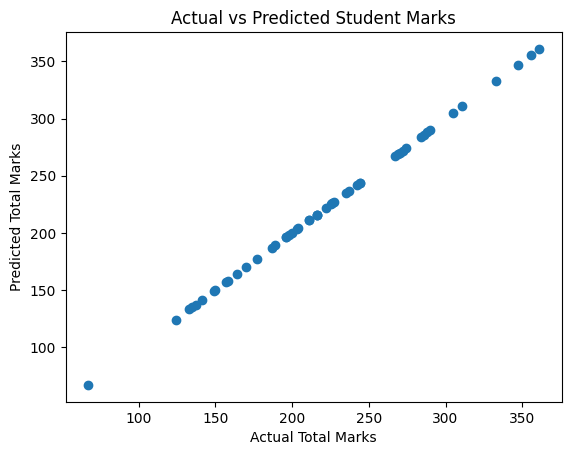

In [85]:
# Visualization (Optional but Powerful)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Total Marks")
plt.ylabel("Predicted Total Marks")
plt.title("Actual vs Predicted Student Marks")
plt.show()


In [86]:
new_student = [[40, 30, 34, 56]]

In [87]:
prediction = model.predict(new_student)

In [88]:
prediction

array([160.])

In [89]:
df.columns

Index(['Gender', 'Age', 'Section', 'Science', 'English', 'History', 'Maths',
       'Total_marks'],
      dtype='object')

In [90]:
import pickle
import os
model_path = os.path.join("..", "model", "student_marks_model.pkl")

with open(model_path, "wb") as file:
    pickle.dump(model, file)

print("✅ Model saved to model folder")


✅ Model saved to model folder
